#Collecting data

In [ ]:
# Instalasi Google Play Scraper dan Googletrans, dan VADER
!pip install vaderSentiment
!pip install textblob
!pip install google-play-scraper
!pip install googletrans==3.1.0a0

from google_play_scraper import app, reviews, Sort
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from googletrans import Translator
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Inisialisasi analyzer VADER
analyzer = SentimentIntensityAnalyzer()

# Mengambil ulasan dari Google Play Store
result, continuation_token = reviews(
    'id.ac.unnes.myunnesmo',
    lang='en_us',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

print(f"Jumlah ulasan yang diambil: {len(result)}")

# Membuat DataFrame dari hasil ulasan
df = pd.DataFrame(np.array(result), columns=['reviews'])
df = df.join(pd.DataFrame(df.pop('reviews').tolist()))

# Preview data
df[['userName', 'content', 'score']].head()

# Terjemahkan konten ulasan
translator = Translator()

# Fungsi untuk menerjemahkan teks
def translate_text(text):
    try:
        return translator.translate(text).text
    except Exception as e:
        return text

df['translated_text'] = df['content'].apply(translate_text)

# Preprocessing teks hasil terjemahan
df['translated_text'] = df['translated_text'].str.replace('([^0-9A-Za-z \t])|(\w+:\/\/\S+)', ' ', regex=True)
df['translated_text'] = df['translated_text'].str.lower()

# Fungsi untuk mendapatkan skor VADER lebih detail
def vader_scores(text):
    return analyzer.polarity_scores(text)

# Fungsi untuk menentukan sentimen berdasarkan nilai compound dari VADER
def vader_sentiment(compound):
    if compound >= 0.05:
        return '+1'  # Positif
    elif compound <= -0.05:
        return '-1'  # Negatif
    else:
        return '0'   # Netral

# Menerapkan analisis VADER pada kolom 'translated_text' dan mendapatkan semua skor
df['vader_scores'] = df['translated_text'].apply(vader_scores)

# Memisahkan skor VADER ke dalam kolom-kolom yang berbeda
df['vader_neg'] = df['vader_scores'].apply(lambda score_dict: score_dict['neg'])
df['vader_neu'] = df['vader_scores'].apply(lambda score_dict: score_dict['neu'])
df['vader_pos'] = df['vader_scores'].apply(lambda score_dict: score_dict['pos'])
df['vader_compound'] = df['vader_scores'].apply(lambda score_dict: score_dict['compound'])

# Menghapus kolom 'vader_scores' setelah dipecah
df = df.drop(columns=['vader_scores'])

# Menambahkan kolom 'vader_sentimen' berdasarkan nilai compound
df['vader_sentimen'] = df['vader_compound'].apply(vader_sentiment)

# Fungsi untuk menghitung subjektivitas dan polaritas Textblob
def subjektivitas(tr_text):
    return TextBlob(tr_text).sentiment.subjectivity

def polaritas(tr_text):
    return TextBlob(tr_text).sentiment.polarity

def hasilSentimen(nilai):
    if nilai < 0:
        return '-1'
    elif nilai == 0:
        return '0'
    else:
        return '+1'

# Menerapkan fungsi ke DataFrame
df['subjektivitas'] = df['translated_text'].apply(subjektivitas)
df['polaritas'] = df['translated_text'].apply(polaritas)
df['textblob_sentimen'] = df['polaritas'].apply(hasilSentimen)

# Preview hasil akhir
df[['userName', 'content', 'translated_text', 'subjektivitas', 'polaritas', 'textblob_sentimen', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_sentimen']].head()
df = df[['userName', 'content', 'translated_text', 'subjektivitas', 'polaritas', 'textblob_sentimen', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_sentimen']]

Jumlah ulasan yang diambil: 54


In [ ]:
# prompt: save df

df.to_csv('reviews_sentimen.csv', index=False)


#Preprocessing

In [ ]:
!pip install Sastrawi nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load the dataset from an Excel file
df_n = pd.read_excel('reviews_sentimen.xlsx')

# Menghapus baris dengan sentimen netral (0)
df = df_n[df_n['sentimen'] != 0]
print(f"Jumlah ulasan tanpa sentimen netral: {len(df)}")

# Print some info or preview the data
print(df.info())
df.head(20)


Jumlah ulasan tanpa sentimen netral: 197
<class 'pandas.core.frame.DataFrame'>
Index: 197 entries, 0 to 266
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   userName           197 non-null    object 
 1   content            197 non-null    object 
 2   translated_text    197 non-null    object 
 3   subjektivitas      197 non-null    float64
 4   polaritas          197 non-null    float64
 5   textblob_sentimen  197 non-null    int64  
 6   vader_neg          197 non-null    float64
 7   vader_neu          197 non-null    float64
 8   vader_pos          197 non-null    float64
 9   vader_compound     197 non-null    float64
 10  vader_sentimen     197 non-null    int64  
 11  manual_sent        197 non-null    int64  
 12  sentimen           197 non-null    int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 21.5+ KB
None


,userName,content,translated_text,subjektivitas,polaritas,textblob_sentimen,vader_neg,vader_neu,vader_pos,vader_compound,vader_sentimen,manual_sent,sentimen
0,Setya Budi Arif Prabowo,Pengalaman selama menggunakan aplikasi myUNNES...,the experience while using the myunnes applica...,0.494167,0.155333,1,0.050,0.810,0.140,0.8101,1,1,1
1,Istifar Riyanti,Aplikasinya sudah bagus tampilannya juga sudah...,the application is good the appearance is als...,0.479167,0.354167,1,0.000,0.751,0.249,0.9359,1,1,1
2,Wisnu Prakoso,Apps ini sangat tak rekomen ketika meminta adu...,i really don t recommend this app when asking ...,0.113333,-0.020000,-1,0.070,0.811,0.119,0.5693,1,-1,-1
3,Ahmad Muyaqi,"Aplikasi sudah cukup bagus, hanya saja fitur y...",the application is quite good it s just that ...,0.675000,0.750000,1,0.000,0.842,0.158,0.8070,1,1,1
4,Andre Ahady,Masukkan untuk UNNES dan mohon untuk didengark...,enter for unnes and ask for it to be listened ...,0.500000,0.300000,1,0.065,0.788,0.148,0.7717,1,1,1
5,mufa zuan,Menurut saya apk ini secara UI sudah bagus unt...,in my opinion the ui of this apk is good for ...,0.523333,0.338333,1,0.000,0.886,0.114,0.8910,1,1,1
6,Rendy Prasatmadja,Saya rasa ada yang perlu dipertimbangkan: 1. K...,i think there are things to consider 1 if th...,0.454630,0.148148,1,0.059,0.816,0.124,0.6130,1,0,1
7,Aries Sukma 15,untuk pemakaian dan tampilan sudah cukup bagus...,for use and appearance it is quite good but so...,0.408333,0.233333,1,0.078,0.706,0.216,0.7389,1,1,1
8,Princes Shopia,Klo fiturnya sama kaya di bot telegram dan mas...,if the features are the same as in the telegra...,0.388258,-0.002273,-1,0.031,0.969,0.000,-0.2263,-1,0,-1
9,Ayu febri Anitasari,"Aplikasinya kurang memadahi, saya harus downlo...",the application is not adequate i had to down...,0.511458,-0.061458,-1,0.082,0.875,0.042,-0.1446,-1,-1,-1


In [ ]:
positive_count = len(df[df['sentimen'] == +1])
negative_count = len(df[df['sentimen'] == -1])

print(f"Jumlah data positif: {positive_count}")
print(f"Jumlah data negatif: {negative_count}")


Jumlah data positif: 115
Jumlah data negatif: 82


In [ ]:
import re
import nltk
import json
import requests
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

# Inisialisasi stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# URL raw file JSON dari GitHub
url = 'https://raw.githubusercontent.com/husniadamramadhan/sentimen_myunnes/main/kamus/nasalsabila_kamus-alay/_json_colloquial-indonesian-lexicon.txt'

# Mendownload dan memuat kamus dari URL GitHub
response = requests.get(url)
kamus = response.text

# Rekonstruksi data sebagai 'dict'
normalization_dict = json.loads(kamus)

# 1. Casefolding (menjadikan huruf kecil)
def casefolding(text):
    return text.lower()

# 2. Cleaning (menghapus karakter khusus dan angka)
def cleaning(text):
    # Tahap-1: Menghapus karakter non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Tahap-2: Simbol
    text = re.sub(r'[!$%^&*@#()_+|~=`{}\[\]%\-:";\'<>?,.\/]', ' ', text)

    # Tahap-3: Angka
    text = re.sub(r'[0-9]+', '', text)

    # Tahap-4: Koreksi duplikasi tiga karakter beruntun atau lebih
    text = re.sub(r'([a-zA-Z])\1\1', '\\1', text)

    # Tahap-5: Spasi ganda (atau lebih) menjadi satu spasi
    text = re.sub(' +', ' ', text)

    # Tahap-6: Spasi di awal dan akhir kalimat
    text = re.sub(r'^[ ]|[ ]$', '', text)
    return text.strip()

# 3. Normalization menggunakan kamus eksternal
def normalize(text, normalization_dict):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return " ".join(normalized_words)

# 4. Stemming (mengubah kata ke bentuk dasar menggunakan Sastrawi)
def stemming(text):
    return stemmer.stem(text)

# Fungsi preprocessing dengan kolom-kolom terpisah
def preprocess_text_columns(text):
    casefolded_text = casefolding(text)
    cleaned_text = cleaning(casefolded_text)
    normalized_text = normalize(cleaned_text, normalization_dict)
    stemmed_text = stemming(normalized_text)
    final_text = stemmed_text

    return pd.Series([casefolded_text, cleaned_text, normalized_text, stemmed_text],
                     index=['casefolding', 'cleaning', 'normalized', 'stemming'])

# Fungsi untuk menghapus baris jika hasil preprocessing menghasilkan kolom kosong di semua kolom
def filter_all_empty_rows(df):
    # Terapkan preprocessing dan tambahkan kolom-kolom baru tanpa mengubah data asli
    df[['casefolding', 'cleaning', 'normalized', 'stemming']] = df['content'].apply(preprocess_text_columns)

    # Filter baris yang memiliki teks kosong di kolom 'stemming'
    df_filtered = df[~(df['stemming'].str.strip() == '')]

    return df_filtered


# Terapkan fungsi filter_all_empty_rows
df_filtered = filter_all_empty_rows(df)

print(df_filtered[['content', 'casefolding', 'cleaning', 'normalized', 'stemming']])
print(f"Jumlah ulasan setelah preprocessing: {len(df_filtered)}")
# Menghitung jumlah ulasan positif (label 1) dan negatif (label -1)
positif_count = df_filtered[df_filtered['sentimen'] == 1].shape[0]
negatif_count = df_filtered[df_filtered['sentimen'] == -1].shape[0]

# Menampilkan hasil jumlah ulasan positif dan negatif
print(f"Jumlah ulasan positif: {positif_count}")
print(f"Jumlah ulasan negatif: {negatif_count}")


                                               content  \
0    Pengalaman selama menggunakan aplikasi myUNNES...   
1    Aplikasinya sudah bagus tampilannya juga sudah...   
2    Apps ini sangat tak rekomen ketika meminta adu...   
3    Aplikasi sudah cukup bagus, hanya saja fitur y...   
4    Masukkan untuk UNNES dan mohon untuk didengark...   
..                                                 ...   
260                                    Bikin ribet anj   
262  Selama sikadu dan elena belum dapat di akses m...   
264                                               Good   
265  gabisa login di chrome setelah install app ini...   
266  Tolong kedepannya mengintegrasikan app unnes y...   

                                           casefolding  \
0    pengalaman selama menggunakan aplikasi myunnes...   
1    aplikasinya sudah bagus tampilannya juga sudah...   
2    apps ini sangat tak rekomen ketika meminta adu...   
3    aplikasi sudah cukup bagus, hanya saja fitur y...   
4    masukkan

<ipython-input-4-8451a963b8b5>:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['casefolding', 'cleaning', 'normalized', 'stemming']] = df['content'].apply(preprocess_text_columns)
<ipython-input-4-8451a963b8b5>:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['casefolding', 'cleaning', 'normalized', 'stemming']] = df['content'].apply(preprocess_text_columns)
<ipython-input-4-8451a963b8b5>:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [ ]:
df_filtered.to_csv('df_filtered.csv', index=False)


In [ ]:
import pandas as pd

df_filtered = pd.read_csv('df_filtered.csv')


#TFIDF

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Melakukan fit dan transformasi pada seluruh dataset sebelum split
tfidf_full = vectorizer.fit_transform(df_filtered['stemming'])

# Membagi data menjadi training set (80%) dan testing set (20%)
tfidf_train, tfidf_test, train_labels, test_labels = train_test_split(
    tfidf_full,
    df_filtered['sentimen'],
    test_size=0.1,
    random_state=31,
    stratify=df_filtered['sentimen']
)

# Cetak dimensi data setelah split
print("Dimensi data training TF-IDF:", tfidf_train.shape)
print("Dimensi data testing TF-IDF:", tfidf_test.shape)


Dimensi data training TF-IDF: (177, 725)
Dimensi data testing TF-IDF: (20, 725)


In [ ]:
import pickle
# Simpan vectorizer yang sudah di-fit ke dalam file pickle
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Simpan juga data tfidf_train ke dalam file pickle
with open('tfidf_full.pkl', 'wb') as f:
    pickle.dump(tfidf_full, f)

#Classification

SVM

Classification Report (SVM):
              precision    recall  f1-score   support

          -1       1.00      0.88      0.93         8
           1       0.92      1.00      0.96        12

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20

Confusion Matrix (SVM):
[[ 7  1]
 [ 0 12]]


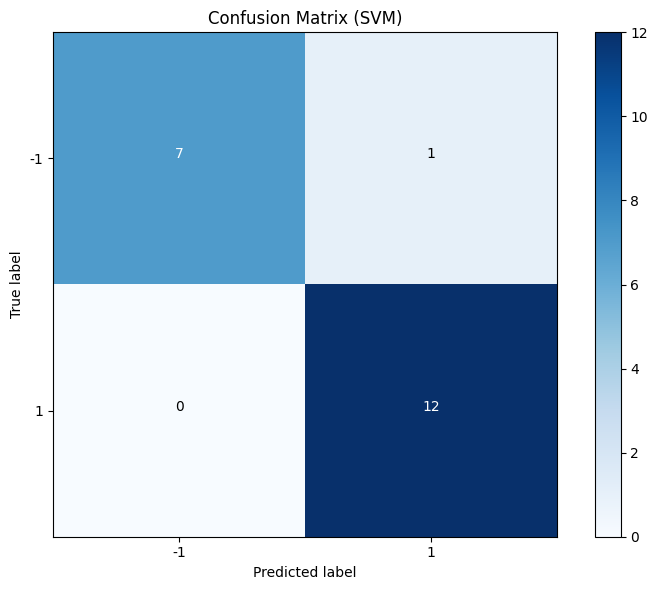

Model SVM telah disimpan ke dalam file 'model_svc.pkl'


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Inisialisasi dan pelatihan model SVM
model_svc = SVC(kernel='linear', C=1)
model_svc.fit(tfidf_train, train_labels)

# Prediksi menggunakan model SVM
y_pred_svc = model_svc.predict(tfidf_test)

# Menampilkan classification report
report = classification_report(test_labels, y_pred_svc)
print("Classification Report (SVM):")
print(report)

# Menampilkan confusion matrix dengan urutan label yang konsisten
labels = sorted(test_labels.unique())  # Urutkan label agar sesuai
conf_matrix = confusion_matrix(test_labels, y_pred_svc, labels=labels)
print("Confusion Matrix (SVM):")
print(conf_matrix)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (SVM)')
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Simpan model SVM yang telah dilatih ke dalam file pickle
with open('model_svc.pkl', 'wb') as model_file:
   pickle.dump(model_svc, model_file)

print("Model SVM telah disimpan ke dalam file 'model_svc.pkl'")

RandomForest

Classification Report (Random Forest):
              precision    recall  f1-score   support

          -1       1.00      0.38      0.55         8
           1       0.71      1.00      0.83        12

    accuracy                           0.75        20
   macro avg       0.85      0.69      0.69        20
weighted avg       0.82      0.75      0.71        20

Confusion Matrix (Random Forest):
[[ 3  5]
 [ 0 12]]


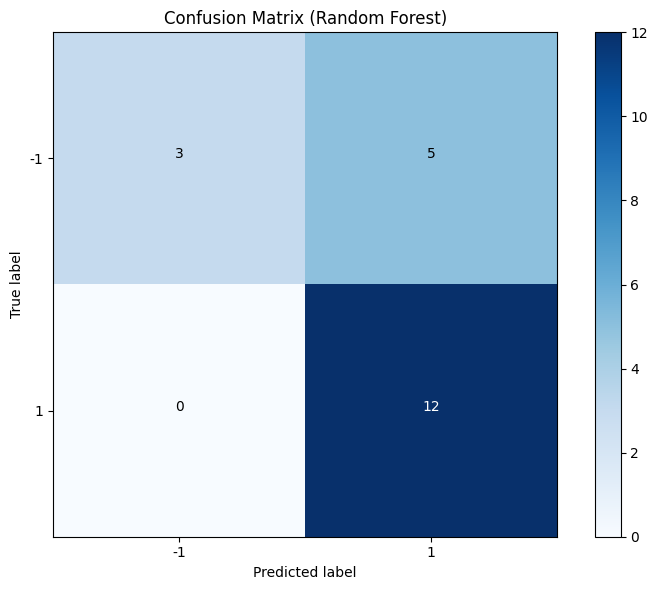

Model Random Forest telah disimpan ke dalam file 'model_rf.pkl'


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Inisialisasi dan pelatihan model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(tfidf_train, train_labels)  # Ganti train_df['sentimen'] dengan train_labels

# Prediksi menggunakan model Random Forest
y_pred_rf = model_rf.predict(tfidf_test)

# Menampilkan classification report
report_rf = classification_report(test_labels, y_pred_rf)
print("Classification Report (Random Forest):")
print(report_rf)

# Mendapatkan label yang ada di dataset test untuk mengurutkan confusion matrix
labels = sorted(test_labels.unique())

# Menampilkan confusion matrix dengan urutan label yang konsisten
conf_matrix_rf = confusion_matrix(test_labels, y_pred_rf, labels=labels)
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_rf, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Random Forest)')
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

thresh = conf_matrix_rf.max() / 2.
for i, j in np.ndindex(conf_matrix_rf.shape):
    plt.text(j, i, format(conf_matrix_rf[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix_rf[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Simpan model Random Forest yang telah dilatih ke dalam file pickle
with open('model_rf.pkl', 'wb') as model_file_rf:
    pickle.dump(model_rf, model_file_rf)

print("Model Random Forest telah disimpan ke dalam file 'model_rf.pkl'")


Naive Bayes

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

          -1       1.00      0.50      0.67         8
           1       0.75      1.00      0.86        12

    accuracy                           0.80        20
   macro avg       0.88      0.75      0.76        20
weighted avg       0.85      0.80      0.78        20

Confusion Matrix (Naive Bayes):
[[ 4  4]
 [ 0 12]]


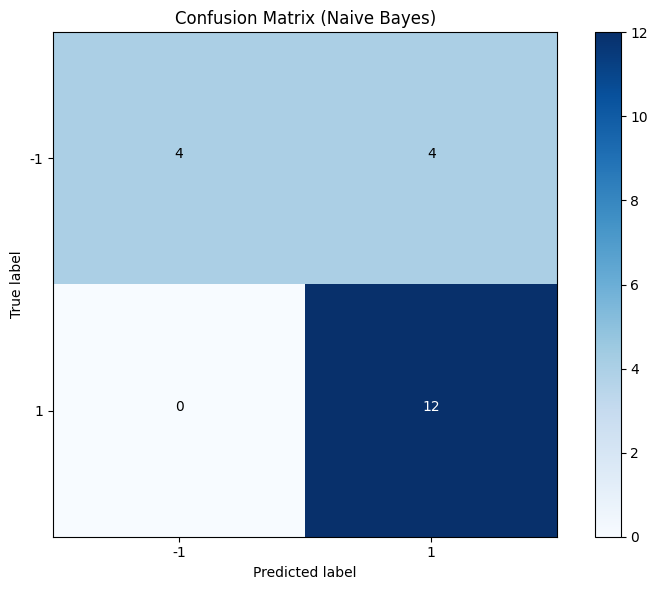

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Inisialisasi dan pelatihan model Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(tfidf_train, train_labels)

# Prediksi menggunakan model
y_pred_nb = model_nb.predict(tfidf_test)

# Menampilkan classification report
report_nb = classification_report(test_labels, y_pred_nb)  # Data label uji yang sesuai
print("Classification Report (Naive Bayes):")
print(report_nb)

# Mendapatkan label yang ada di dataset test untuk mengurutkan confusion matrix
labels = sorted(test_labels.unique())

# Menampilkan confusion matrix dengan urutan label yang konsisten
conf_matrix_nb = confusion_matrix(test_labels, y_pred_nb, labels=labels)
print("Confusion Matrix (Naive Bayes):")
print(conf_matrix_nb)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_nb, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Naive Bayes)')
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

thresh = conf_matrix_nb.max() / 2.
for i, j in np.ndindex(conf_matrix_nb.shape):
    plt.text(j, i, format(conf_matrix_nb[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix_nb[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Simpan model SVM yang telah dilatih ke dalam file pickle
with open('model_nb.pkl', 'wb') as model_file_nb:
    pickle.dump(model_nb, model_file_nb)

#print("Model NB telah disimpan ke dalam file 'model_nb.pkl'")